# Pyro vs Bnpyro

This notebook compares two probabilistic programming approaches in Python:

| | **Pyro** | **Bnpyro** |
|---|---|---|
| Paradigm | Stochastic program + MCMC/VI | Generative program -> exact BN |
| Inference | Approximate (MCMC, SVI) or exact (discrete enum) | Exact (Variable Elimination) |
| Variables | Continuous and discrete natively | Continuous (discretized) + discrete |
| Strength | Flexible, scalable, `plate` | Exact posteriors, interpretable BN graph |

We compare on three models:
1. **Discrete BN** — Rain / Sprinkler / WetGrass (exact inference in both)
2. **Plates** — Coin bias estimation (`pyro.plate` vs `bn.plate` thunk)
3. **Continuous model** — NUTS (Pyro) vs discretization (Bnpyro)

In [25]:
import sys, os
if os.path.basename(os.getcwd()) != 'src':
    sys.path.insert(0, 'src')

import io, contextlib
from timeit import timeit
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as sp_beta

import torch
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.infer import infer_discrete, config_enumerate, MCMC, NUTS

from Bnpyro import BNppl
from distributions import Normal, Uniform, Beta, Bernoulli

torch.manual_seed(42)
pyro.set_rng_seed(42)

def _posterior_mean(p_dict):
    """Compute mean and std from a Bnpyro query result dict {label: prob}."""
    def mid(s):
        lo = float(s.split(';')[0].lstrip('['))
        hi = float(s.split(';')[1].rstrip(']').rstrip('['))
        return (lo + hi) / 2
    items = [(mid(k), v) for k, v in p_dict.items()]
    e1 = sum(m * p for m, p in items)
    e2 = sum(m**2 * p for m, p in items)
    return e1, (e2 - e1**2) ** 0.5

## Part 1 — Discrete BN: Rain / Sprinkler / WetGrass

The classic Bayesian Network with three binary variables.

```
P(Rain = T)  = 0.5

P(Sprinkler = T | Rain = F) = 0.5
P(Sprinkler = T | Rain = T) = 0.5

P(Wet = T | Rain=F, Spr=F) = 0.0
P(Wet = T | Rain=F, Spr=T) = 0.5
P(Wet = T | Rain=T, Spr=F) = 0.5
P(Wet = T | Rain=T, Spr=T) = 1.0
```

**Query**: `P(Rain = T | WetGrass = T)`

### Exact analytical answer

```
P(Rain=T, Wet=T) = 0.5 × (0.5×0.5 + 0.5×1.0) = 0.5 × 0.75 = 0.375
P(Rain=F, Wet=T) = 0.5 × (0.5×0.0 + 0.5×0.5) = 0.5 × 0.25 = 0.125
P(Wet=T)         = 0.375 + 0.125               = 0.500

P(Rain=T | Wet=T) = 0.375 / 0.500 = 3/4 = 0.750000  (exact rational)
```

Both Pyro and Bnpyro should return **exactly 0.75** — no rounding, no approximation.

In [26]:
# Pyro — exact discrete inference 
# Strategy: enumerate all 8 joint states (2^3) using PyTorch tensors.
# This is exactly what infer_discrete does internally (sum-product algorithm).
pyro.clear_param_store()

p_rain      = torch.tensor([0.5, 0.5])           # [P(R=F), P(R=T)]
p_s_given_r = torch.tensor([[0.5, 0.5],          # R=F: [P(S=F|R=F), P(S=T|R=F)]
                              [0.5, 0.5]])         # R=T: [P(S=F|R=T), P(S=T|R=T)]
p_wet_T     = torch.tensor([[0.0, 0.5],           # R=F: [P(W=T|R=F,S=F), P(W=T|R=F,S=T)]
                              [0.5, 1.0]])          # R=T: [P(W=T|R=T,S=F), P(W=T|R=T,S=T)]

# Joint P(R, S, W=T) = P(R) × P(S|R) × P(W=T|R,S)
joint = p_rain.unsqueeze(1) * p_s_given_r * p_wet_T   # shape [2, 2]

# Marginalize over Sprinkler: P(R, W=T)
p_r_wet = joint.sum(dim=1)

# Normalize: P(R | W=T)
p_r_given_wet_pyro = p_r_wet / p_r_wet.sum()

print(f"P(Rain=T | Wet=T)  [Pyro exact enumeration]  = {p_r_given_wet_pyro[1].item():.6f}")
print(f"Expected: 3/4 = 0.75")

# Also define the Pyro generative model (same probabilities) for infer_discrete
@config_enumerate
def rain_pyro(obs_wet=None):
    rain      = pyro.sample("rain",      dist.Bernoulli(0.5))
    sprinkler = pyro.sample("sprinkler", dist.Bernoulli(0.5))
    p_wet_table = torch.tensor([[0.0, 0.5], [0.5, 1.0]])
    p_wet = p_wet_table[rain.long(), sprinkler.long()]
    pyro.sample("wetgrass", dist.Bernoulli(p_wet), obs=obs_wet)

P(Rain=T | Wet=T)  [Pyro exact enumeration]  = 0.750000
Expected: 3/4 = 0.75


In [27]:
# Bnpyro — exact BN inference 
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    bn = BNppl()
    rain      = bn.sample("rain",      Bernoulli(0.5))
    sprinkler = bn.sample("sprinkler", bn.where(rain, 0.5, 0.5))
    wetgrass  = bn.sample("wetgrass",  bn.where(rain,
                    bn.where(sprinkler, 1.0, 0.5),   # rain=T: [spr=T, spr=F]
                    bn.where(sprinkler, 0.5, 0.0)    # rain=F: [spr=T, spr=F]
               ))
    bn.compile()

p_rain_bn = bn.query("rain", evidence={"wetgrass": True})["True"]
print(f"P(Rain=T | Wet=T)  [Bnpyro exact BN]         = {p_rain_bn:.6f}")
print(f"Expected: 3/4 = 0.75")
print()
print(f"Both match: {abs(p_r_given_wet_pyro[1].item() - p_rain_bn) < 1e-9}")

P(Rain=T | Wet=T)  [Bnpyro exact BN]         = 0.750000
Expected: 3/4 = 0.75

Both match: True


In [28]:
# Speed comparison 
obs = torch.tensor(1.0)

# Pyro: exact enumeration via tensor ops
def pyro_exact():
    joint     = p_rain.unsqueeze(1) * p_s_given_r * p_wet_T
    p_r_wet   = joint.sum(dim=1)
    return (p_r_wet / p_r_wet.sum())[1]

# Pyro: infer_discrete (samples from exact posterior — one sample per call)
posterior_pyro = infer_discrete(rain_pyro, first_available_dim=-1)
def pyro_sample():
    return poutine.trace(posterior_pyro).get_trace(obs_wet=obs).nodes["rain"]["value"]

t_pyro_exact  = timeit(pyro_exact,  number=500) / 500 * 1000
t_pyro_sample = timeit(pyro_sample, number=200) / 200 * 1000
t_bn          = timeit(lambda: bn.query("rain", evidence={"wetgrass": True}), number=200) / 200 * 1000

print(f"Pyro exact enumeration (tensor ops)   : {t_pyro_exact:.3f} ms")
print(f"Pyro infer_discrete (1 posterior sample): {t_pyro_sample:.2f} ms")
print(f"Bnpyro exact BN query                  : {t_bn:.2f} ms")
print()
print("Note: Bnpyro returns the full posterior distribution P(Rain | Wet=T) in one call.")
print("      Pyro infer_discrete returns one sample; estimating P(Rain=T|...) requires N calls.")

Pyro exact enumeration (tensor ops)   : 0.016 ms
Pyro infer_discrete (1 posterior sample): 2.32 ms
Bnpyro exact BN query                  : 0.27 ms

Note: Bnpyro returns the full posterior distribution P(Rain | Wet=T) in one call.
      Pyro infer_discrete returns one sample; estimating P(Rain=T|...) requires N calls.


## Part 2 — Plates: Coin Bias Estimation

**Model**: `θ ~ Beta(2, 2)`,  `flip_i | θ ~ Bernoulli(θ)` for i = 1..N  
**Observations**: 6 heads and 2 tails (8 flips total)  
**Query**: posterior `P(θ | flips)` -> exact answer is `Beta(8, 4)`

### Key difference: `pyro.plate` vs `bn.plate` (thunk)

| | Pyro | Bnpyro |
|---|---|---|
| Syntax | `with pyro.plate("flips", N):` | `coin = bn.plate(...)` then `coin()` × N |
| Mechanism | Vectorized batch — **one site** in the trace | N explicit BN nodes, each with a CPT |
| Graph size | O(1) code and memory regardless of N | O(N) nodes — grows with N |
| **Thunk** | `pyro.plate` is a context manager | `bn.plate` returns a **callable** (thunk from λ!-calculus) |

The thunk `coin = bn.plate(...)` represents a **reusable resource** `!t` in the λ!-calculus.  
Each call `coin()` is a **dereliction** `der t`, creating an independent copy of the node.

In [29]:
# Pyro — plate syntax 
pyro.clear_param_store()
data = torch.tensor([1., 1., 1., 1., 1., 1., 0., 0.])  # 6 heads, 2 tails

def coin_pyro(data):
    theta = pyro.sample("theta", dist.Beta(2.0, 2.0))
    # pyro.plate: one line handles N i.i.d. observations
    with pyro.plate("flips", len(data)):
        pyro.sample("flip", dist.Bernoulli(theta), obs=data)

nuts_coin  = NUTS(coin_pyro)
mcmc_coin  = MCMC(nuts_coin, num_samples=2000, warmup_steps=400, disable_progbar=True)
mcmc_coin.run(data)

theta_pyro = mcmc_coin.get_samples()["theta"]
print(f"Pyro MCMC (NUTS)       — E[θ | data] = {theta_pyro.mean():.4f}  std = {theta_pyro.std():.4f}")
print(f"Analytical Beta(8, 4)  — E[θ]       = {8/12:.4f}  std = {(8*4/(12**2*13))**0.5:.4f}")

Pyro MCMC (NUTS)       — E[θ | data] = 0.6648  std = 0.1341
Analytical Beta(8, 4)  — E[θ]       = 0.6667  std = 0.1307


In [30]:
# Bnpyro — bn.plate thunk
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    bn_coin = BNppl(n_bins=30)
    theta   = bn_coin.sample("theta", Beta(2.0, 2.0))

    # bn.plate returns a thunk: each call creates a new Bernoulli node sharing theta
    coin    = bn_coin.plate("flip", lambda t: Bernoulli(t), parents=[theta])
    flips   = [coin() for _ in range(len(data))]  # creates flip_1 .. flip_8

    bn_coin.compile()

# Condition on observed data (True = heads, False = tails)
evidence = {f"flip_{i+1}": bool(data[i].item()) for i in range(len(data))}
p_theta_bn = bn_coin.query("theta", evidence=evidence)

e_theta, std_theta = _posterior_mean(p_theta_bn)
print(f"Bnpyro exact BN        — E[θ | data] = {e_theta:.4f}  std = {std_theta:.4f}")
print(f"Analytical Beta(8, 4)  — E[θ]       = {8/12:.4f}")
print(f"\nBN nodes created: {len(bn_coin.gum_bn.names())} (theta + {len(data)} flip nodes)")
print("Compare: Pyro plate created 1 vectorized site for the same 8 observations.")

Bnpyro exact BN        — E[θ | data] = 0.6666  std = 0.1307
Analytical Beta(8, 4)  — E[θ]       = 0.6667

BN nodes created: 9 (theta + 8 flip nodes)
Compare: Pyro plate created 1 vectorized site for the same 8 observations.


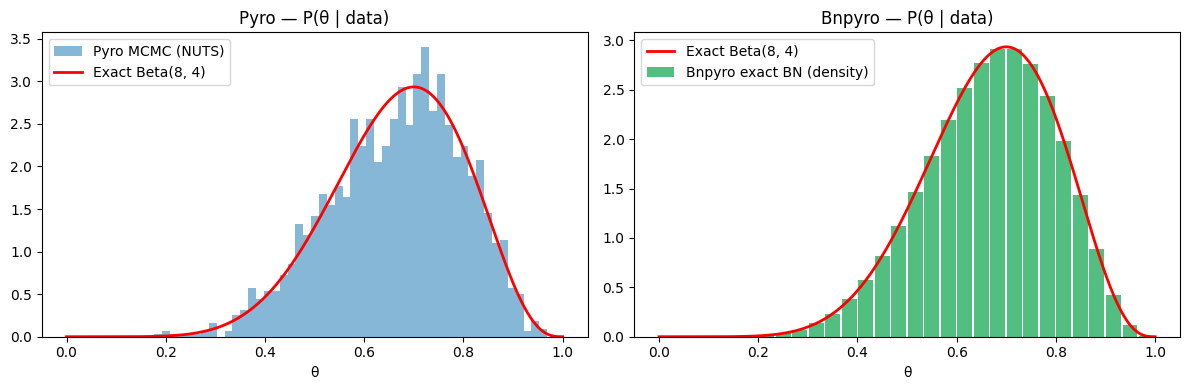

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = np.linspace(0, 1, 300)

# Pyro posterior
axes[0].hist(theta_pyro.numpy(), bins=50, density=True,
             color='#5499C7', alpha=0.7, label='Pyro MCMC (NUTS)')
axes[0].plot(xs, sp_beta.pdf(xs, 8, 4), 'r-', lw=2, label='Exact Beta(8, 4)')
axes[0].set_title('Pyro — P(θ | data)')
axes[0].set_xlabel('θ'); axes[0].legend()

# Bnpyro posterior
lbls = sorted(p_theta_bn.keys(), key=lambda s: float(s.split(';')[0].lstrip('[')))
mids = [(float(l.split(';')[0].lstrip('[')) + float(l.split(';')[1].rstrip(']').rstrip('['))) / 2
        for l in lbls]
wid  = mids[1] - mids[0] if len(mids) > 1 else 0.03
axes[1].bar(mids, [p_theta_bn[l] / wid for l in lbls], width=wid * 0.9,
            color='#27AE60', alpha=0.8, label='Bnpyro exact BN (density)')
axes[1].plot(xs, sp_beta.pdf(xs, 8, 4), 'r-', lw=2, label='Exact Beta(8, 4)')
axes[1].set_title('Bnpyro — P(θ | data)')
axes[1].set_xlabel('θ'); axes[1].legend()

plt.tight_layout()
plt.show()

## Part 3 — Continuous Model

**Model**: `μ ~ Normal(0, 1)`,  `σ ~ Uniform(0.5, 2)`,  `X | μ, σ ~ Normal(μ, σ)`  
**Observation**: `X = 3`  
**Query**: posterior `P(μ | X=3)` and `P(σ | X=3)`

| | Pyro (NUTS) | Bnpyro |
|---|---|---|
| Approach | MCMC in continuous space | Discretize μ and σ, exact BN inference |
| μ, σ representation | True continuous samples | Histogram over bins |
| Inference quality | Approximate (converges to true posterior) | Exact given discretization |
| Error source | MCMC variance (reducible) | Binning error (reducible by ↑ n_bins) |

In [32]:
# Pyro — NUTS 
pyro.clear_param_store()

def cont_model(x_obs=None):
    mu    = pyro.sample("mu",    dist.Normal(0.0, 1.0))
    sigma = pyro.sample("sigma", dist.Uniform(0.5, 2.0))
    pyro.sample("x", dist.Normal(mu, sigma), obs=x_obs)

nuts_c = NUTS(cont_model)
mcmc_c = MCMC(nuts_c, num_samples=3000, warmup_steps=500, disable_progbar=True)
mcmc_c.run(x_obs=torch.tensor(3.0))

mu_samples    = mcmc_c.get_samples()["mu"]
sigma_samples = mcmc_c.get_samples()["sigma"]
print(f"Pyro NUTS — E[μ | X=3] = {mu_samples.mean():.4f}  std = {mu_samples.std():.4f}")
print(f"          — E[σ | X=3] = {sigma_samples.mean():.4f}  std = {sigma_samples.std():.4f}")

Pyro NUTS — E[μ | X=3] = 1.0338  std = 0.9128
          — E[σ | X=3] = 1.4641  std = 0.3751


In [33]:
# Bnpyro — discretize + exact inference 
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    bn_cont    = BNppl(n_bins=25)
    mu_node    = bn_cont.sample("mu",    Normal(0.0, 1.0))
    sigma_node = bn_cont.sample("sigma", Uniform(0.5, 2.0))
    x_node     = bn_cont.sample("x",     lambda m, s: Normal(m, s),
                                parents=[mu_node, sigma_node])
    bn_cont.compile()

# Find the bin index containing x=3
x_obs_val = 3.0
x_ticks   = x_node.ticks
x_bin     = int(np.searchsorted(x_ticks, x_obs_val, side='right')) - 1
x_bin     = max(0, min(x_bin, bn_cont.gum_bn.variable('x').domainSize() - 1))

p_mu_bn    = bn_cont.query("mu",    evidence={"x": x_bin})
p_sigma_bn = bn_cont.query("sigma", evidence={"x": x_bin})

e_mu, std_mu       = _posterior_mean(p_mu_bn)
e_sigma, std_sigma = _posterior_mean(p_sigma_bn)
print(f"Bnpyro exact BN — E[μ | X≈3] = {e_mu:.4f}  std = {std_mu:.4f}")
print(f"                — E[σ | X≈3] = {e_sigma:.4f}  std = {std_sigma:.4f}")

Bnpyro exact BN — E[μ | X≈3] = 0.9946  std = 0.8776
                — E[σ | X≈3] = 1.4311  std = 0.3868


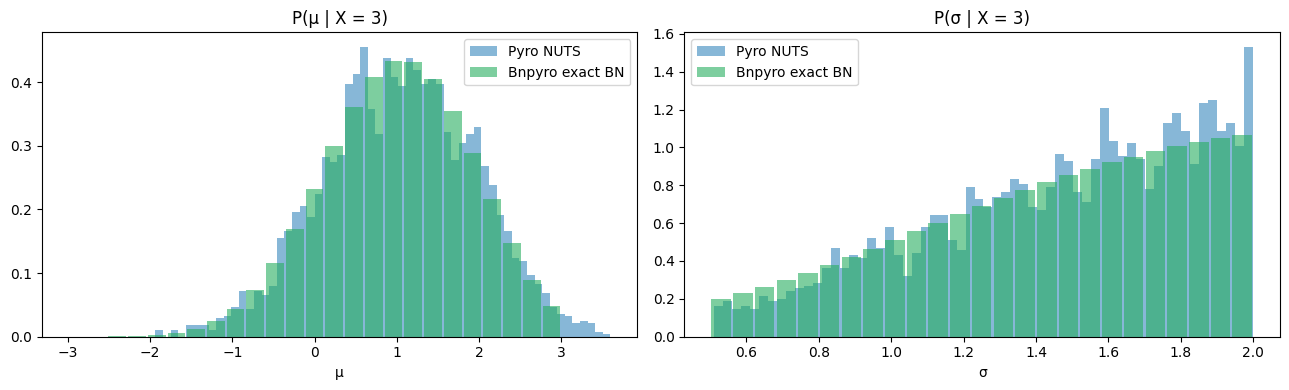

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

def _plot_bn_posterior(ax, p_dict, label, color):
    lbls = sorted(p_dict.keys(), key=lambda s: float(s.split(';')[0].lstrip('[')))
    mids = [(float(l.split(';')[0].lstrip('[')) + float(l.split(';')[1].rstrip(']').rstrip('['))) / 2
            for l in lbls]
    wid  = mids[1] - mids[0] if len(mids) > 1 else 0.1
    ax.bar(mids, [p_dict[l] / wid for l in lbls], width=wid * 0.9,
           color=color, alpha=0.6, label=label)

# μ posterior
axes[0].hist(mu_samples.numpy(), bins=60, density=True,
             color='#5499C7', alpha=0.7, label='Pyro NUTS')
_plot_bn_posterior(axes[0], p_mu_bn, 'Bnpyro exact BN', '#27AE60')
axes[0].set_title('P(μ | X = 3)')
axes[0].set_xlabel('μ'); axes[0].legend()

# σ posterior
axes[1].hist(sigma_samples.numpy(), bins=60, density=True,
             color='#5499C7', alpha=0.7, label='Pyro NUTS')
_plot_bn_posterior(axes[1], p_sigma_bn, 'Bnpyro exact BN', '#27AE60')
axes[1].set_title('P(σ | X = 3)')
axes[1].set_xlabel('σ'); axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

| Criterion | Pyro | Bnpyro |
|---|---|---|
| **Discrete models** | `@config_enumerate` + `infer_discrete` -> exact | `bn.where` nested -> exact BN (CPT) |
| **Plates** | `pyro.plate` -> vectorized, O(1) code | `bn.plate` thunk -> N explicit nodes, O(N) |
| **Continuous models** | NUTS / HMC -> truly continuous, approximate | Discretize -> exact given binning error |
| **Posterior result** | Samples (histogram) | Full discrete distribution |
| **Interpretability** | Code-level | Explicit BN graph + CPTs |
| **Scalability** | High (GPU, plate, stochastic VI) | Medium (CPT size = n_bins^(k+1)) |

**When to use Bnpyro**: small/medium models where exact posteriors and an interpretable BN graph matter.  
**When to use Pyro**: large models, many observations (plate), deep latent structure, or truly continuous posteriors.